# KTP Associate Pre-Interview Data Analysis Exercise

## Question 1: What are the key features of the dataset?

This notebook focuses on the dataset structure, quality, and characteristics that matter for later stability analysis.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['start_date', 'pull_date', 'set_down_day', 'exposure_days', 'oven', 'temp_c', 'rh', 'analyst', 'assay_s1', 'assay_s2', 'imp092_s1', 'imp092_s2', 'imp123_s1', 'imp123_s2']
lot_a_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.185, 8.119, 0.288, 0.282, 0.074, 0.074], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 11.184, 10.702, 0.246, 0.215, 0.134, 0.136], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.1, 12.238, 0.222, 0.222, 0.191, 0.189], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.518, 11.095, 0.651, 0.673, 0.167, 0.171], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.813, 11.294, 0.527, 0.541, 0.176, 0.176], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.72, 11.687, 0.314, 0.289, 0.165, 0.164], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.286, 8.409, 0.51, 0.472, 0.125, 0.126], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.519, 10.643, 0.527, 0.564, 0.186, 0.184], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.34, 12.46, 0.184, 0.178, 0.198, 0.2], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.533, 12.545, 0.165, 0.165, 0.207, 0.211], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 11.912, 12.063, 0.269, 0.273, 0.194, 0.193], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 12.172, 12.178, 0.179, 0.165, 0.25, 0.246], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.281, 12.215, 0.282, 0.279, 0.297, 0.295], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.946, 11.323, 0.535, 0.544, 0.474, 0.478], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.197, 11.597, 0.573, 0.451, 0.38, 0.39], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.951, 11.909, 0.379, 0.384, 0.615, 0.621], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.039, 12.41, 0.136, 0.132, 0.386, 0.382], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.006, 12.464, 0.223, 0.211, 0.506, 0.512], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 12.15, 11.877, 0.302, 0.289, 0.748, 0.746], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.79, 12.808, 0, 0, 0.082, 0.068]]
lot_b_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.439, 7.993, 0.304, 0.287, 0.113, 0.113], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 10.463, 10.676, 0.279, 0.213, 0.207, 0.205], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.278, 12.321, 0.253, 0.241, 0.312, 0.316], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.054, 11.439, 0.737, 0.7, 0.242, 0.238], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.504, 11.413, 0.575, 0.558, 0.287, 0.291], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.653, 11.998, 0.343, 0.328, 0.271, 0.269], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.677, 8.406, 0.472, 0.491, 0.174, 0.174], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.33, 10.621, 0.52, 0.465, 0.25, 0.252], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.171, 12.14, 0.186, 0.186, 0.305, 0.309], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.308, 12.387, 0.166, 0.17, 0.309, 0.307], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 12.206, 11.714, 0.288, 0.296, 0.31, 0.316], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 11.83, 11.734, 0.19, 0.169, 0.332, 0.326], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.419, 12.228, 0.291, 0.301, 0.424, 0.432], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.829, 10.606, 0.583, 0.531, 0.546, 0.542], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.32, 11.16, 0.607, 0.576, 0.517, 0.515], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.677, 12.051, 0.454, 0.426, 0.773, 0.771], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.307, 12.258, 0.134, 0.135, 0.482, 0.48], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.137, 12.155, 0.236, 0.232, 0.658, 0.65], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 11.733, 12.053, 0.314, 0.312, 0.888, 0.882], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.493, 12.72, 0, 0, 0.143, 0.143]]
df_a = pd.DataFrame(lot_a_rows, columns=cols)
df_b = pd.DataFrame(lot_b_rows, columns=cols)
df_a['lot'] = 'A014'
df_b['lot'] = 'B025'
df = pd.concat([df_a, df_b], ignore_index=True)
for col_name in ['start_date', 'pull_date']:
    df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
df.head()


,start_date,pull_date,set_down_day,exposure_days,oven,temp_c,rh,analyst,assay_s1,assay_s2,imp092_s1,imp092_s2,imp123_s1,imp123_s2,lot
0,2025-12-18,2026-01-08,0,21,Oven 2,70,11,RG,8.185,8.119,0.288,0.282,0.074,0.074,A014
1,2025-12-18,2026-01-08,0,21,Oven 4,65,25,SS,11.184,10.702,0.246,0.215,0.134,0.136,A014
2,2025-12-18,2026-01-08,0,21,Oven 1,50,64,SS,12.100,12.238,0.222,0.222,0.191,0.189,A014
3,2025-12-18,2026-01-08,0,21,Oven 3,60,80,CM,11.518,11.095,0.651,0.673,0.167,0.171,A014
4,2025-12-18,2026-01-08,0,21,Oven 3,60,42,CM,11.813,11.294,0.527,0.541,0.176,0.176,A014


In [2]:
metric_map = {'assay':['assay_s1','assay_s2'], 'imp092':['imp092_s1','imp092_s2'], 'imp123':['imp123_s1','imp123_s2']}
eda_df = df.copy()
for metric_name, pair_cols in metric_map.items():
    eda_df[metric_name + '_mean'] = eda_df[pair_cols].mean(axis=1)
    eda_df[metric_name + '_range'] = eda_df[pair_cols].max(axis=1) - eda_df[pair_cols].min(axis=1)
eda_df['is_control'] = eda_df['exposure_days'].eq(0)
for col_name in ['temp_c', 'rh', 'exposure_days', 'set_down_day']:
    eda_df[col_name] = pd.to_numeric(eda_df[col_name], errors='coerce')
summary_df = pd.DataFrame({
    'feature':['Rows','Lots','Control rows','Non-control rows','Temperature levels','RH levels','Exposure-day levels'],
    'value':[len(eda_df), eda_df['lot'].nunique(), int(eda_df['is_control'].sum()), int((~eda_df['is_control']).sum()), eda_df.loc[~eda_df['is_control'],'temp_c'].nunique(), eda_df.loc[~eda_df['is_control'],'rh'].nunique(), eda_df.loc[~eda_df['is_control'],'exposure_days'].nunique()]
})
quality_df = pd.DataFrame({
    'check':['Missing start dates','Missing pull dates','Duplicate row count','Rows with any missing analytical values'],
    'value':[int(eda_df['start_date'].isna().sum()), int(eda_df['pull_date'].isna().sum()), int(eda_df.duplicated().sum()), int(eda_df[['assay_s1','assay_s2','imp092_s1','imp092_s2','imp123_s1','imp123_s2']].isna().any(axis=1).sum())]
})
replicate_df = eda_df.groupby('lot')[['assay_range','imp092_range','imp123_range']].agg(['mean','median','max']).round(4)
summary_df
quality_df
replicate_df


assay_range               imp092_range                imp123_range  \
            mean median    max         mean  median    max         mean   
lot                                                                       
A014      0.2101  0.131  0.519       0.0182  0.0105  0.122       0.0036   
B025      0.2172  0.218  0.492       0.0200  0.0160  0.066       0.0034   

                    
     median    max  
lot                 
A014  0.002  0.014  
B025  0.003  0.008

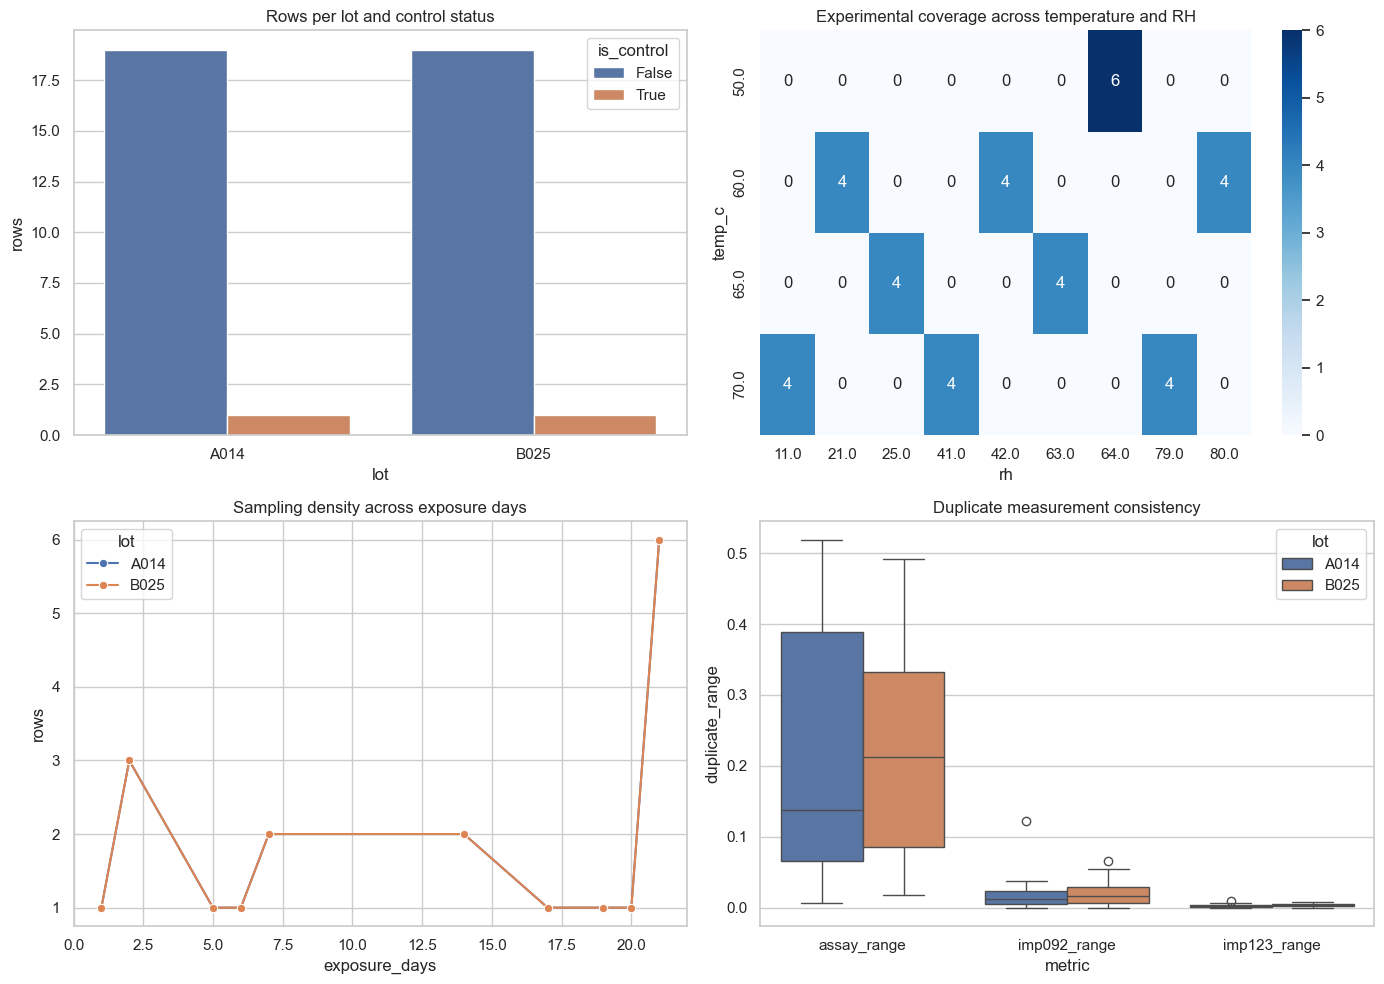

In [3]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
lot_count_df = eda_df.groupby(['lot','is_control']).size().reset_index(name='rows')
sns.barplot(data=lot_count_df, x='lot', y='rows', hue='is_control', ax=axes[0,0])
axes[0,0].set_title('Rows per lot and control status')
non_control_view = eda_df.loc[~eda_df['is_control']].copy()
heat_df = non_control_view.groupby(['temp_c','rh']).size().reset_index(name='count').pivot(index='temp_c', columns='rh', values='count').fillna(0)
sns.heatmap(heat_df, annot=True, fmt='.0f', cmap='Blues', ax=axes[0,1])
axes[0,1].set_title('Experimental coverage across temperature and RH')
exp_day_df = non_control_view.groupby(['lot','exposure_days']).size().reset_index(name='rows')
sns.lineplot(data=exp_day_df.sort_values('exposure_days'), x='exposure_days', y='rows', hue='lot', marker='o', ax=axes[1,0])
axes[1,0].set_title('Sampling density across exposure days')
range_long_df = non_control_view.melt(id_vars=['lot'], value_vars=['assay_range','imp092_range','imp123_range'], var_name='metric', value_name='duplicate_range')
sns.boxplot(data=range_long_df, x='metric', y='duplicate_range', hue='lot', ax=axes[1,1])
axes[1,1].set_title('Duplicate measurement consistency')
plt.tight_layout()
plt.show()


## Key observations

The dataset contains 40 rows in total, split evenly across the two lots, including one control row per lot. It is a small accelerated-stability dataset with deliberate variation in temperature, humidity, and exposure duration. The analytical measurements are duplicated at each test point, which is helpful for checking measurement consistency.

The data quality is generally good. There are no missing analytical results, no exact duplicate rows, and the only missing dates are the two control rows where no exposure period applies. The duplicate measurements are closely aligned for the impurity variables and reasonably close for assay, suggesting acceptable repeatability.

The main limitations are structural rather than clerical. Each formulation is represented by only one lot, the total sample size is modest, and not every temperature and humidity combination is observed across many time points. That means the dataset is strong enough for exploratory analysis and simple modelling, but not strong enough for definitive kinetic conclusions or a robust formulation ranking on its own.
